In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# ==============================================================================
# 1. SETUP AND DATA LOADING
# ==============================================================================

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'Arial' # Use a modern font
df = pd.read_csv("Netflix Dataset.csv")

print("--- Data Loaded ---")
print(f"Initial Dataset size: {len(df)} records.")
print("\n")

--- Data Loaded ---
Initial Dataset size: 7789 records.




In [9]:
# ==============================================================================
# 2. DATA CLEANING AND PREPROCESSING
# ==============================================================================

df.dropna(subset=['Release_Date'], inplace=True)
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Year'] = df['Release_Date'].dt.year
df = df[df['Release_Year'] >= 2008].copy()
df['Country'].fillna('Unknown', inplace=True)

print("--- Data Cleaned and Preprocessed ---")
print(f"Dataset size after cleaning: {len(df)} records.")
print("\n")

--- Data Cleaned and Preprocessed ---
Dataset size after cleaning: 7779 records.




/tmp/ipython-input-1491770984.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna('Unknown', inplace=True)


--- Running Objective 1: Movies vs. TV Shows Analysis ---


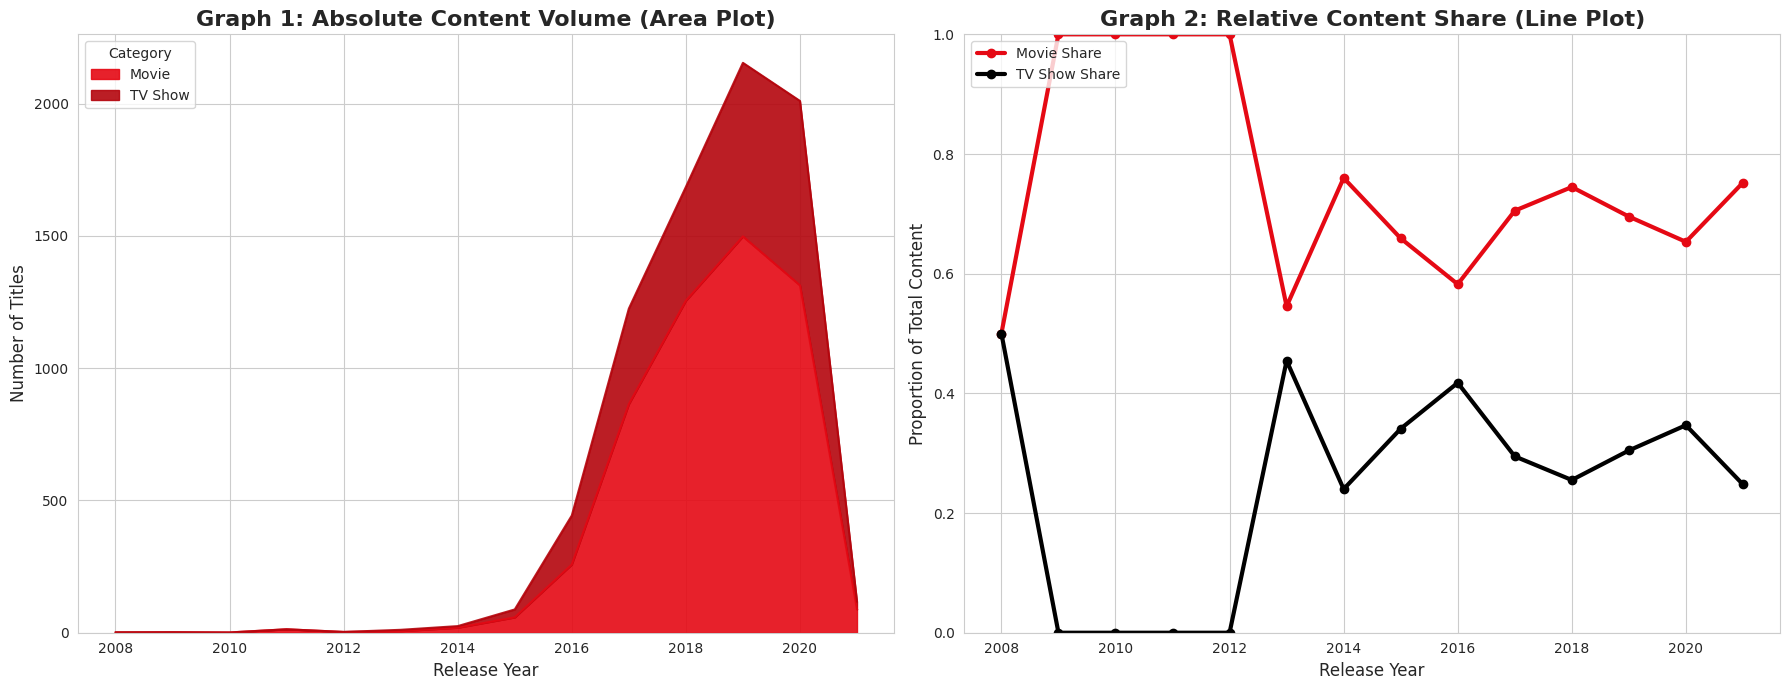

Objective 1 Plots Saved: content_volume_share_by_year.png (Area Plot & Line Plot)


In [10]:
# ==============================================================================
# 3. OBJECTIVE 1: Movies vs. TV Shows Distribution Over Time (2 GRAPHS: Area & Line)
# ==============================================================================

print("--- Running Objective 1: Movies vs. TV Shows Analysis ---")

content_trend = df.groupby(['Release_Year', 'Category']).size().unstack(fill_value=0)
content_trend['Total'] = content_trend['Movie'] + content_trend['TV Show']
content_trend['Movie_Share'] = content_trend['Movie'] / content_trend['Total']
content_trend['TV_Show_Share'] = content_trend['TV Show'] / content_trend['Total']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
content_trend[['Movie', 'TV Show']].plot(kind='area', stacked=True, ax=axes[0],
                                         color=['#E50914', '#B4050D'], alpha=0.9)
axes[0].set_title('Graph 1: Absolute Content Volume (Area Plot)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Release Year', fontsize=12)
axes[0].set_ylabel('Number of Titles', fontsize=12)
axes[0].legend(title='Category', loc='upper left')
content_trend[['Movie_Share', 'TV_Show_Share']].plot(kind='line', ax=axes[1],
                                                    color=['#E50914', '#000000'], linewidth=3, marker='o', markersize=6)
axes[1].set_title('Graph 2: Relative Content Share (Line Plot)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Release Year', fontsize=12)
axes[1].set_ylabel('Proportion of Total Content', fontsize=12)
axes[1].legend(['Movie Share', 'TV Show Share'], loc='upper left')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('content_volume_share_by_year.png')
plt.show()
print("Objective 1 Plots Saved: content_volume_share_by_year.png (Area Plot & Line Plot)")

--- Running Objective 2: Genre Trend Analysis ---


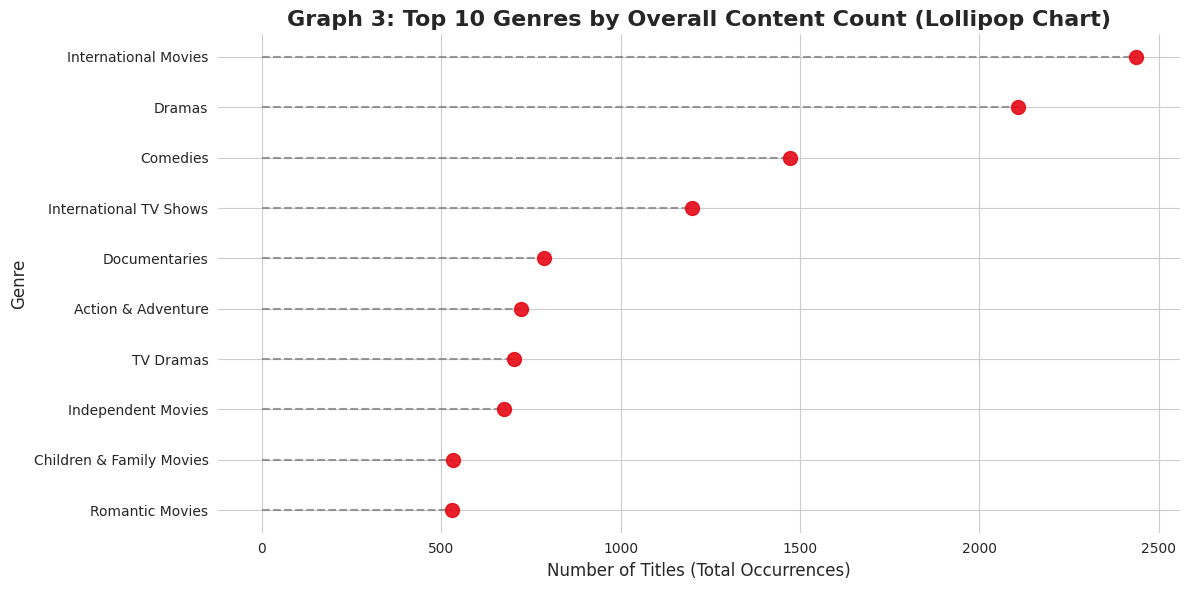

Objective 2 Plot 1 Saved: top_10_genres_lollipop_chart.png


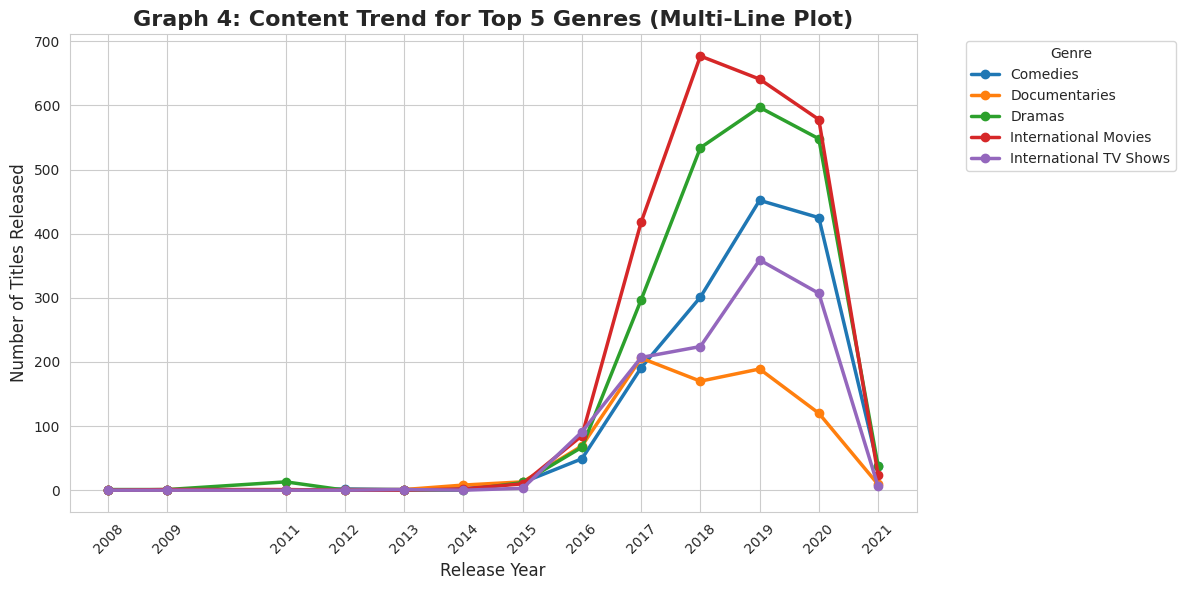

Objective 2 Plot 2 Saved: top_5_genres_trend.png




In [11]:
# ==============================================================================
# 4. OBJECTIVE 2: Genre Trend Analysis (2 GRAPHS: Lollipop & Line)
# ==============================================================================

print("--- Running Objective 2: Genre Trend Analysis ---")
df_genres = df.copy()
df_genres['Genre'] = df_genres['Type'].str.split(', ')
df_genres_exploded = df_genres.explode('Genre')
top_10_genres = df_genres_exploded['Genre'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.hlines(y=top_10_genres.index, xmin=0, xmax=top_10_genres.values, color='gray', alpha=0.8, linewidth=1.5, linestyles='--')
plt.plot(top_10_genres.values, top_10_genres.index, "o", markersize=10, color='#E50914', alpha=0.9)
plt.title('Graph 3: Top 10 Genres by Overall Content Count (Lollipop Chart)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles (Total Occurrences)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.gca().invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('top_10_genres_lollipop_chart.png')
plt.show()
print("Objective 2 Plot 1 Saved: top_10_genres_lollipop_chart.png")
top_5_genre_list = top_10_genres.index[:5].tolist()
df_top_5_genres_trend = df_genres_exploded[df_genres_exploded['Genre'].isin(top_5_genre_list)]
genre_trend = df_top_5_genres_trend.groupby(['Release_Year', 'Genre']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
genre_trend.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2.5)
plt.title('Graph 4: Content Trend for Top 5 Genres (Multi-Line Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles Released', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(genre_trend.index.values, rotation=45)
plt.tight_layout()
plt.savefig('top_5_genres_trend.png')
plt.show()
print("Objective 2 Plot 2 Saved: top_5_genres_trend.png")
print("\n")

/tmp/ipython-input-780516096.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_countries.index, x=top_10_countries.values, palette=sns.light_palette("darkred", reverse=True, n_colors=10))


--- Running Objective 3: Country Contribution Analysis ---


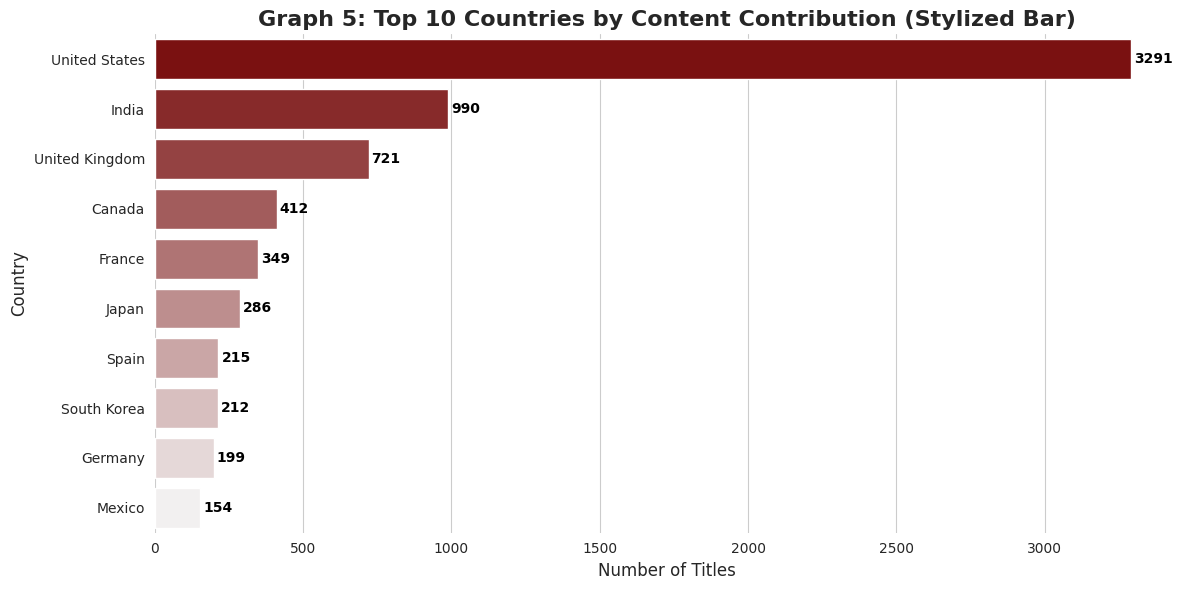

Objective 3 Plot Saved: top_10_countries_stylized_bar.png




In [12]:
# ==============================================================================
# 5. OBJECTIVE 3: Country-wise Content Contributions (1 GRAPH: Stylized Bar)
# ==============================================================================

print("--- Running Objective 3: Country Contribution Analysis ---")

df_country = df.copy()
df_country['Country_Name'] = df_country['Country'].str.split(', ')
df_country_exploded = df_country.explode('Country_Name')

top_10_countries = df_country_exploded['Country_Name'].value_counts()
top_10_countries = top_10_countries[top_10_countries.index != 'Unknown'].head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_10_countries.index, x=top_10_countries.values, palette=sns.light_palette("darkred", reverse=True, n_colors=10))

for i, v in enumerate(top_10_countries.values):
    plt.text(v + 10, i, str(v), color='black', va='center', fontweight='bold')
plt.title('Graph 5: Top 10 Countries by Content Contribution (Stylized Bar)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('top_10_countries_stylized_bar.png')
plt.show()
print("Objective 3 Plot Saved: top_10_countries_stylized_bar.png")
print("\n")

--- Running Bonus Analysis: Content Rating Distribution ---


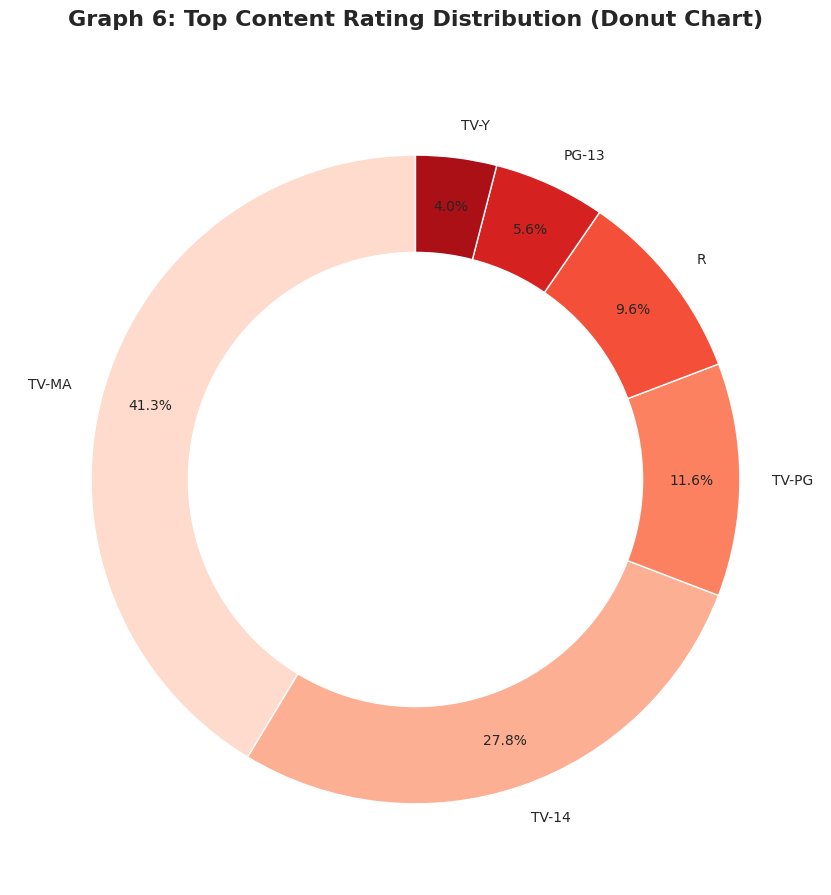

Bonus Plot Saved: top_ratings_donut_chart.png

--- Analysis Complete: 6 Diverse Graphs Generated ---


In [13]:
# ==============================================================================
# 6. BONUS ANALYSIS: Content Rating Distribution (1 GRAPH: Donut Chart)
# ==============================================================================

print("--- Running Bonus Analysis: Content Rating Distribution ---")
df_ratings_top = df['Rating'].fillna('Unknown Rating').value_counts().head(6)

plt.figure(figsize=(9, 9))
plt.pie(df_ratings_top.values, labels=df_ratings_top.index, autopct='%1.1f%%',
        startangle=90, pctdistance=0.85, colors=sns.color_palette("Reds", n_colors=len(df_ratings_top)))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Graph 6: Top Content Rating Distribution (Donut Chart)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('top_ratings_donut_chart.png')
plt.show()
print("Bonus Plot Saved: top_ratings_donut_chart.png")
print("\n--- Analysis Complete: 6 Diverse Graphs Generated ---")